# fourier_transform for parts specific track sections
https://docs.scipy.org/doc/scipy/reference/tutorial/fft.html

In [1]:
#import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import scipy.fftpack
#import scipy.fft
import os
import csv
import re
import glob
import matplotlib.patches as patches
from fourier_functions import *
from coordinate_conversion_functions import *
from track_plotting_daniel import *

## select part of a track to fourier transform

#### read in track and plot it

        Unnamed: 0          time  xc  x_center  yc  y_center  \
200000      200000  15:01:13.054   x   -0.0167   y   25.6224   

        x_head_corrected  y_head_corrected  x_tail_corrected  y_tail_corrected  
200000         -0.216298          26.14741          0.091606         25.105324  


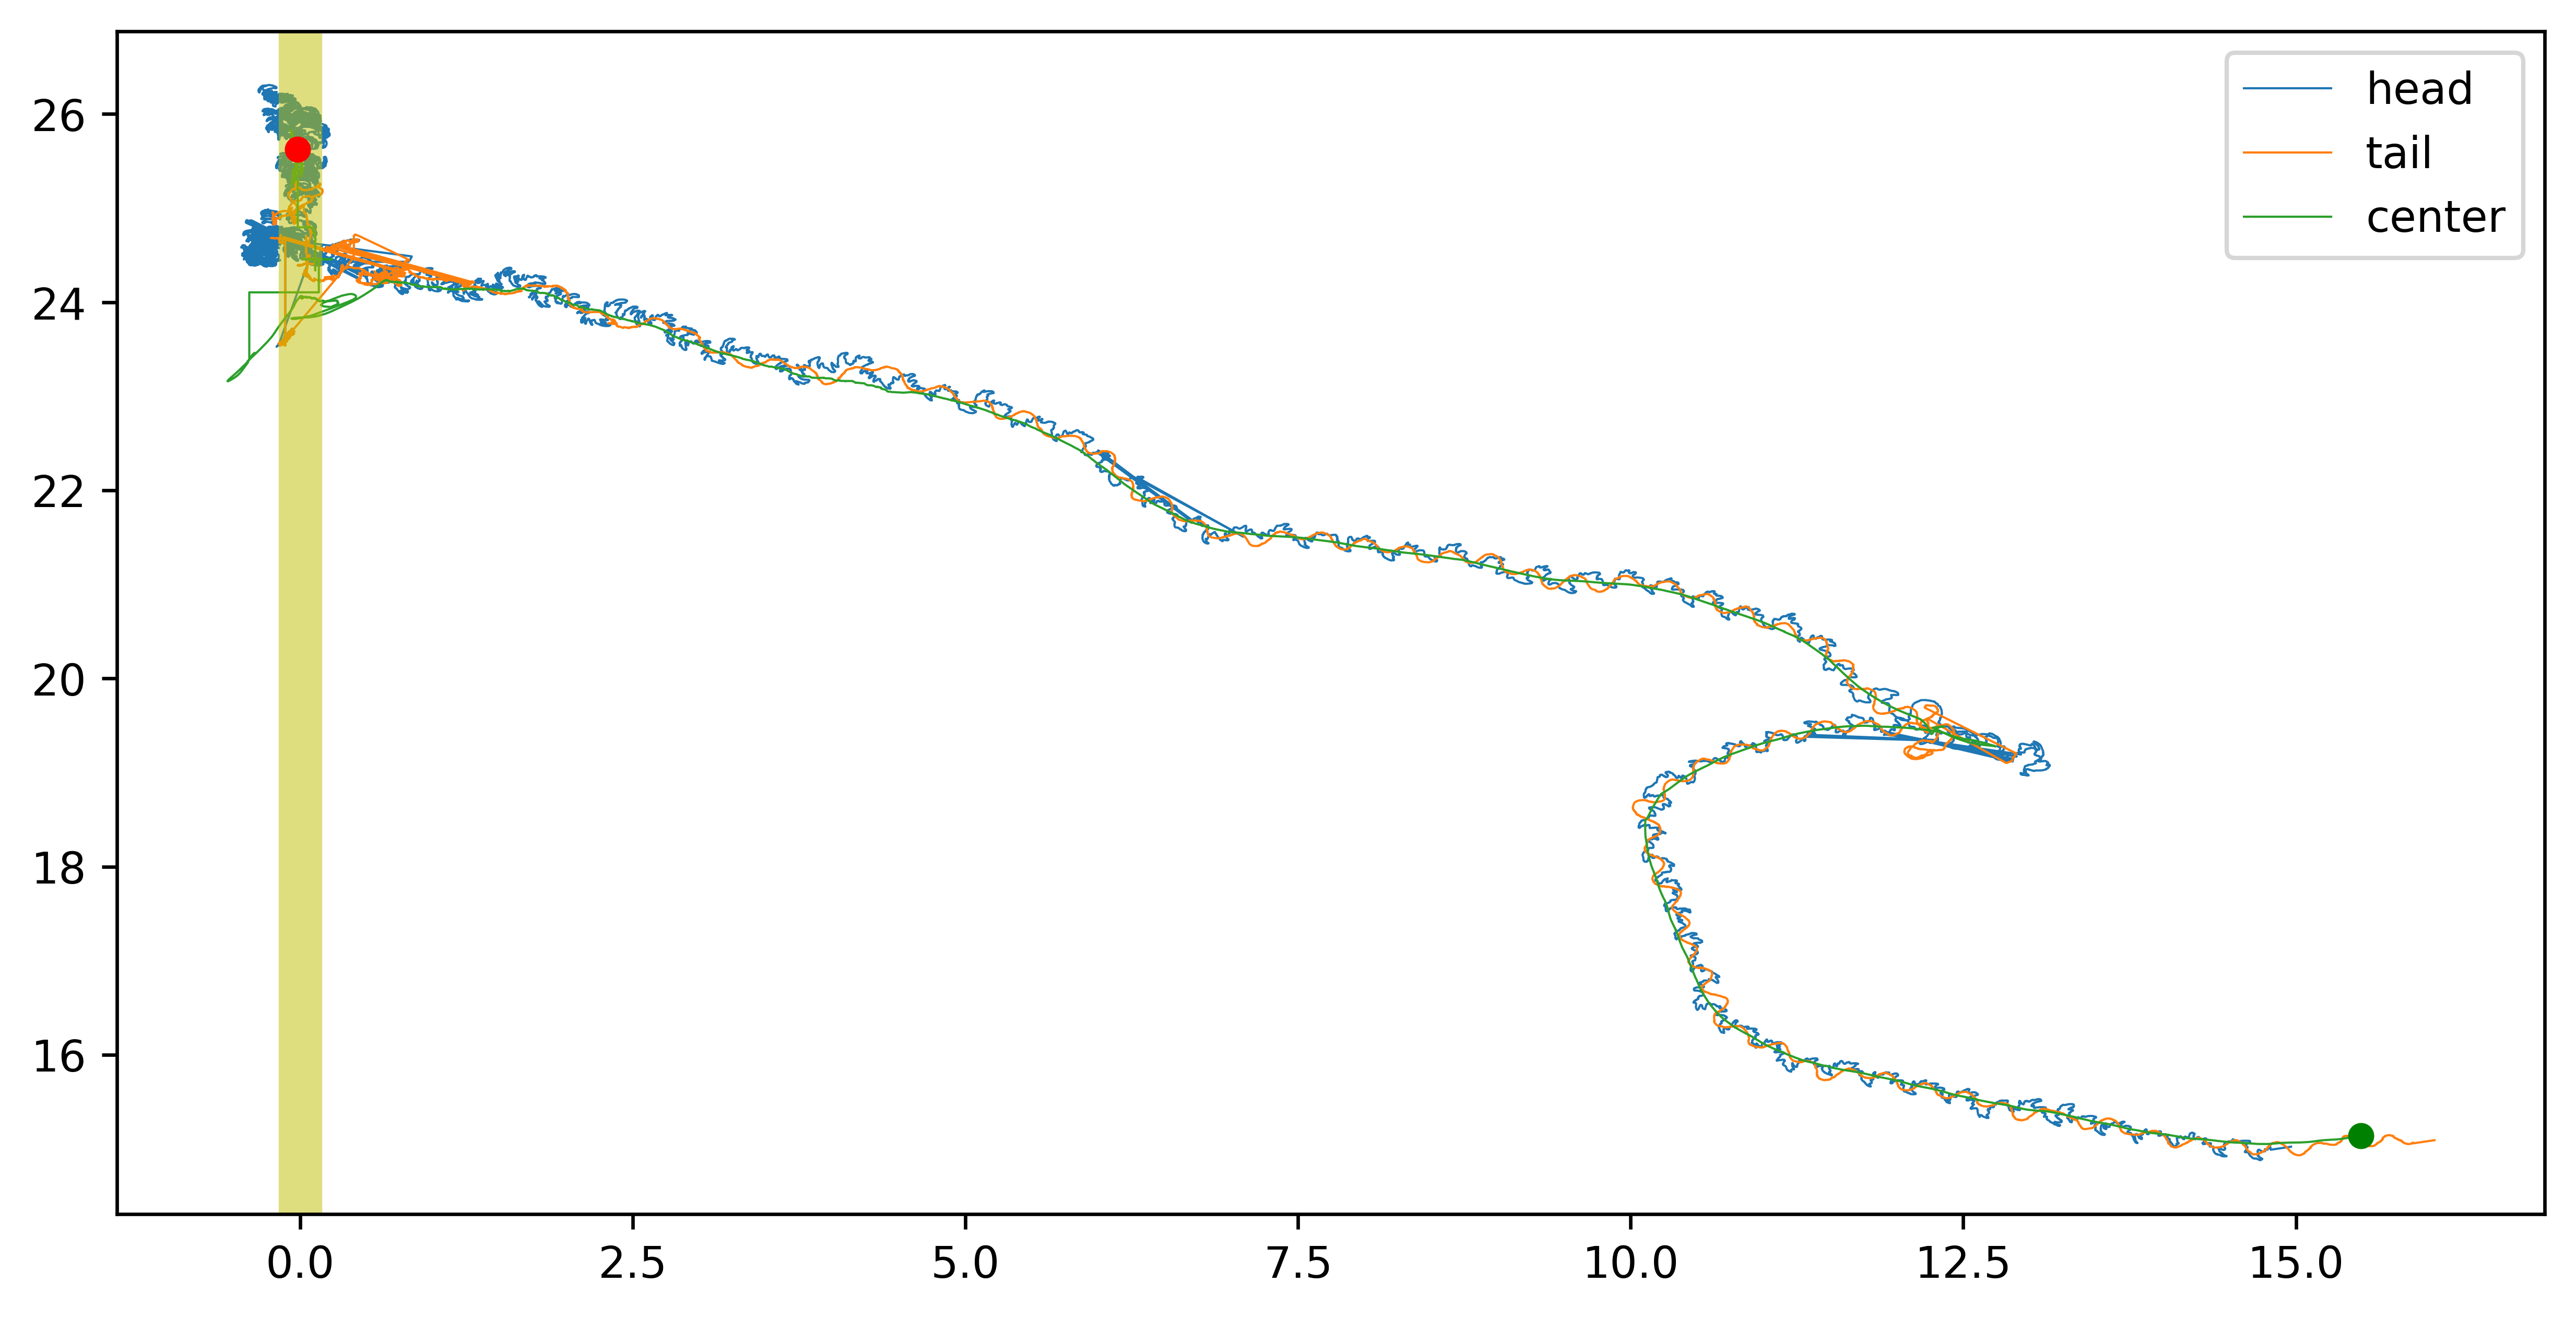

In [2]:
#these are csvs i created with the head_position script 
path='/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected/2020-07-01_14-41-11_chemotaxisl_worm2-TablePosRecord.csv'
df_head_tail_center_coords=pd.read_csv(path)
figsize_x=10
figsize_y=5
line_width=0.5
plot_tracks_center_head_tail(path,figsize_x,figsize_y,line_width)

#### choose part of a track

In [3]:
#here i pull out timeframes where the worm is either awy form food chemotaxing or in the food, in order to compare 
#it with fourier transformation
worm_pos=df_head_tail_center_coords[(df_head_tail_center_coords['x_head_corrected'].between(11, 14)) & 
(df_head_tail_center_coords['y_head_corrected']< 18)]               
xmin=worm_pos['x_head_corrected'].min()
xmax=worm_pos['x_head_corrected'].max()
ymin=worm_pos['y_head_corrected'].min()
ymax=worm_pos['y_head_corrected'].max()

In [4]:
print(worm_pos.index.min())
print(worm_pos.index.max())

1696
9604


        Unnamed: 0          time  xc  x_center  yc  y_center  \
200000      200000  15:01:13.054   x   -0.0167   y   25.6224   

        x_head_corrected  y_head_corrected  x_tail_corrected  y_tail_corrected  
200000         -0.216298          26.14741          0.091606         25.105324  


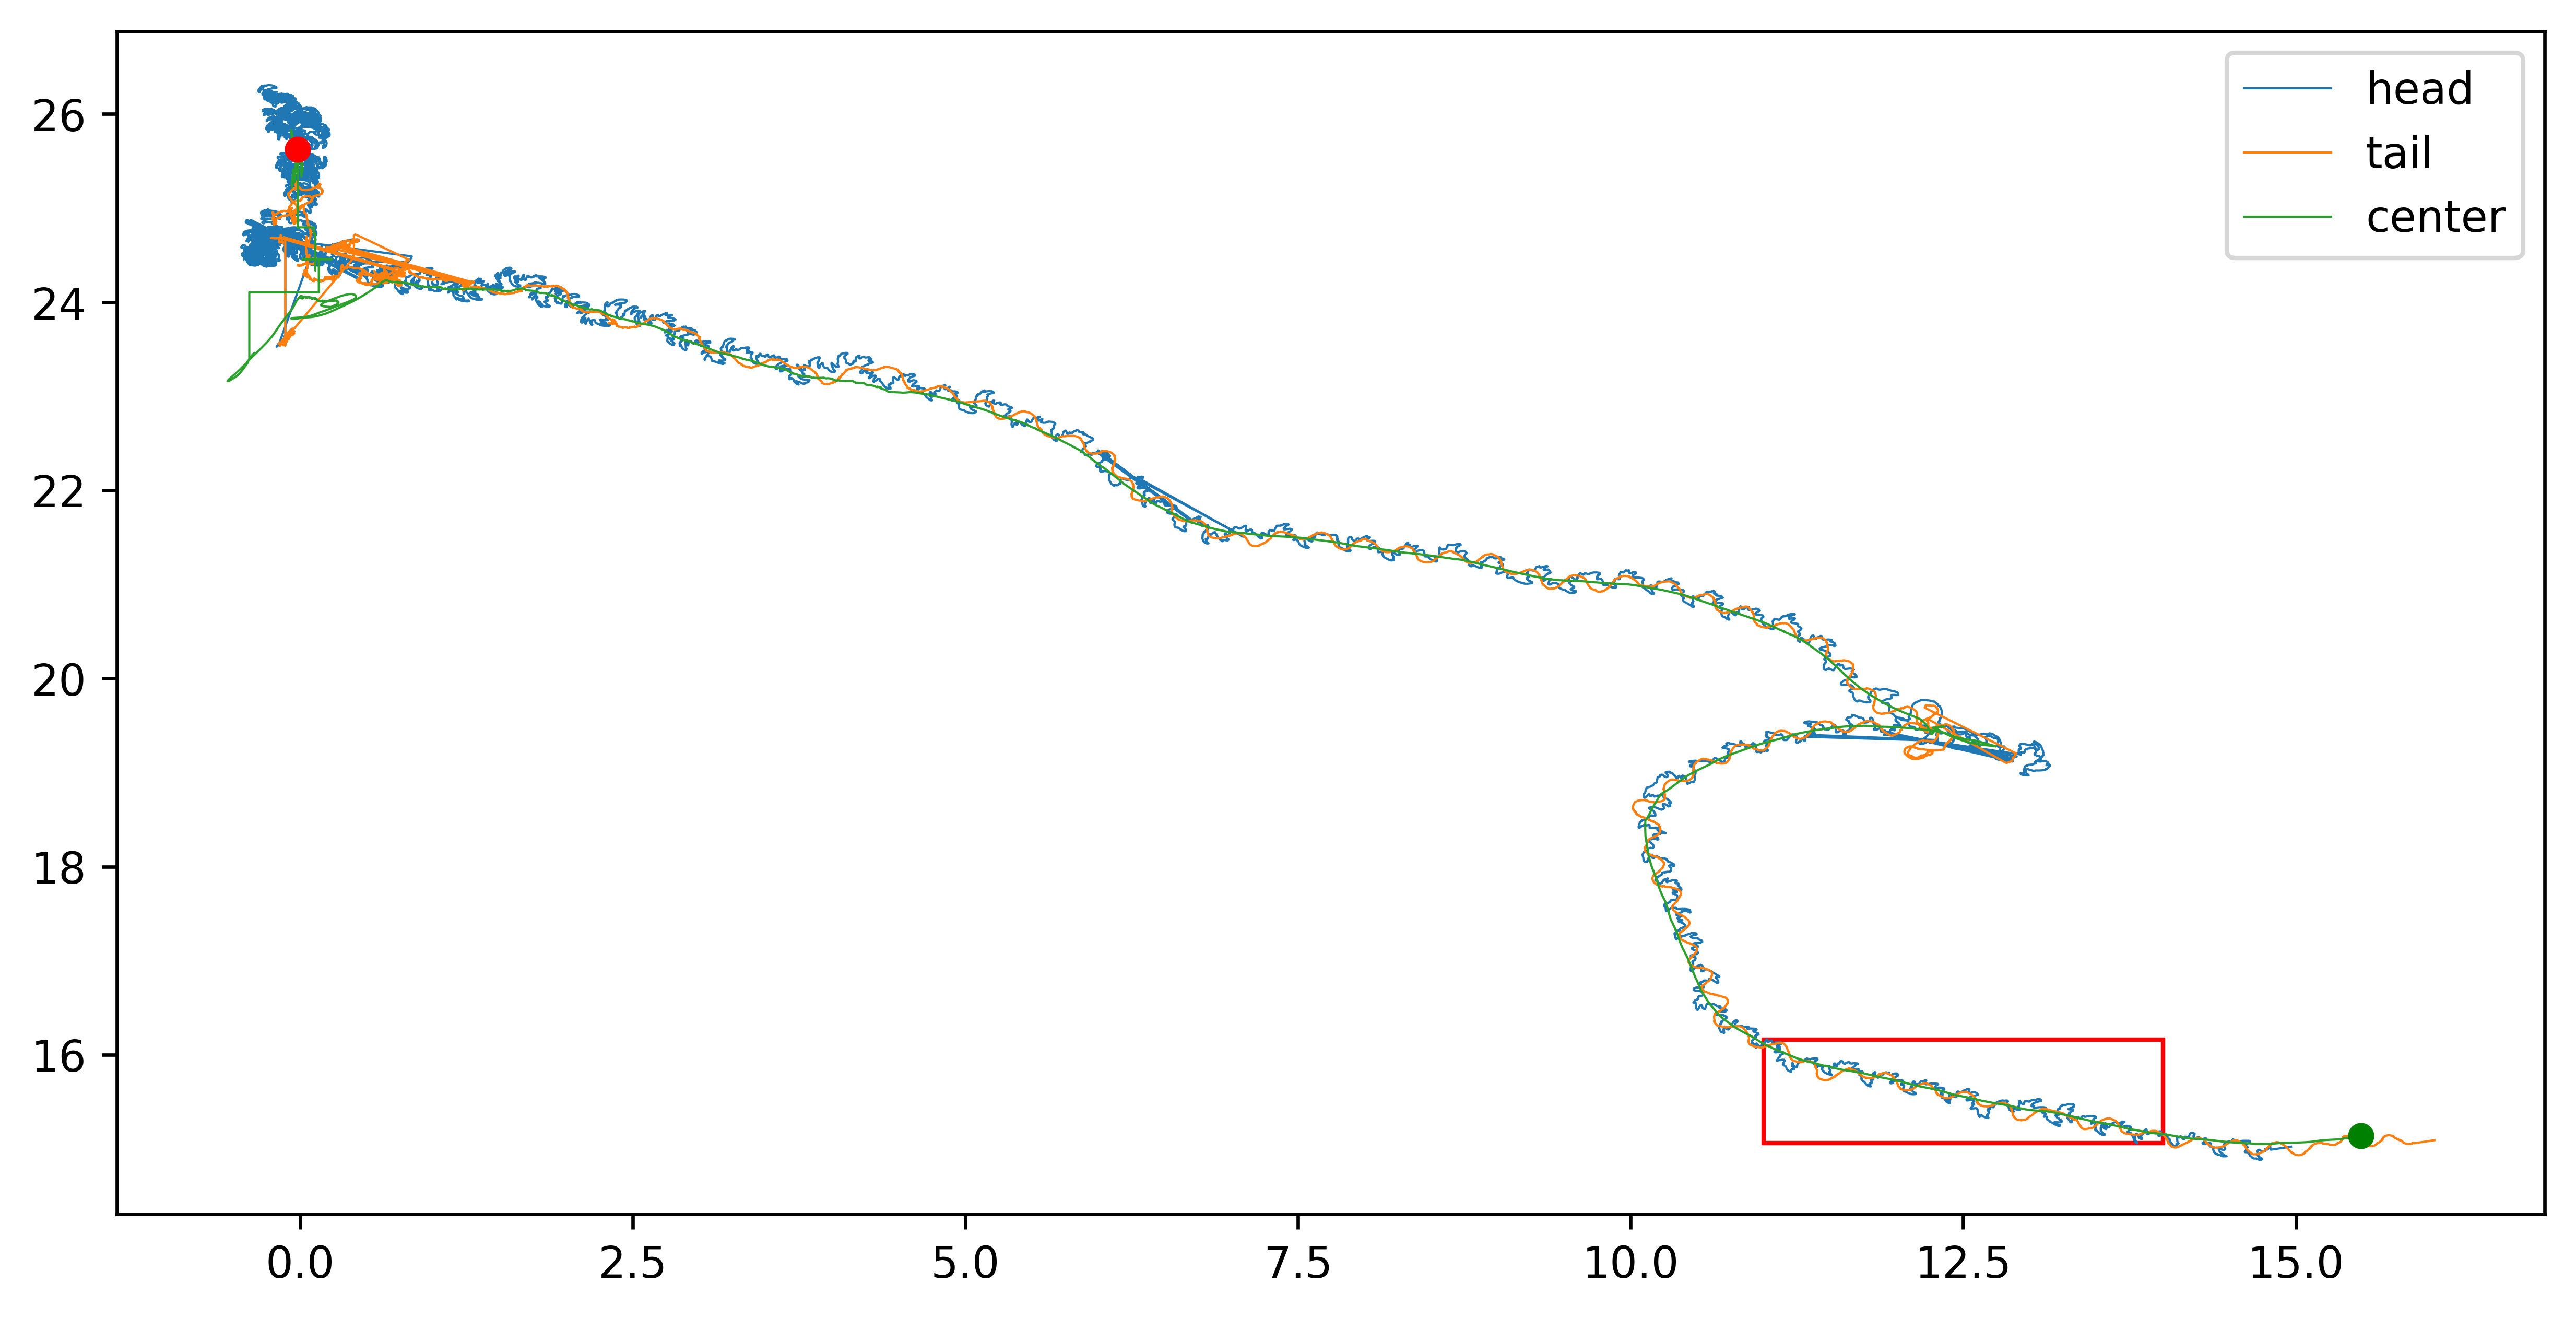

In [5]:
#plot the track to determine on which parts in want to do the fourier transformations
figsize_x=10
figsize_y=5
line_width=0.5
x_head_corrected=df_head_tail_center_coords['x_head_corrected']
y_head_corrected=df_head_tail_center_coords['y_head_corrected']
x_tail_corrected=df_head_tail_center_coords['x_tail_corrected']
y_tail_corrected=df_head_tail_center_coords['y_tail_corrected']
x_center_pos=df_head_tail_center_coords['x_center']
y_center_pos=df_head_tail_center_coords['y_center']
print(df_head_tail_center_coords.tail(1))
fig3, ax3 = plt.subplots(1,1, figsize = (figsize_x,figsize_y), dpi=600)
ax3.plot(x_head_corrected,y_head_corrected,label="head",linewidth=line_width)
ax3.plot(x_tail_corrected,y_tail_corrected,label="tail",linewidth=line_width)
ax3.plot(x_center_pos,y_center_pos,label="center",linewidth=line_width)
ax3.plot(df_head_tail_center_coords['x_center'][0],df_head_tail_center_coords['y_center'][0], 'go', markersize=5)
ax3.plot(df_head_tail_center_coords['x_center'].tail(1),df_head_tail_center_coords['y_center'].tail(1), 'ro', markersize=5)
xposition = [worm_pos['x_head_corrected'].min(), worm_pos['x_head_corrected'].max()]

rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=1, edgecolor='r', facecolor='none')
ax3.add_patch(rect)
ax3.legend()

## applying the fourier transform to choosen part of the track

####  loading curvature data

In [6]:
#load data
#csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv'
csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_17-01-27_chemotaxis_worm6_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]


#### average over a number of segments

In [7]:
win=5 
Kt_avg=segment_averaging(K,win)

number of rows and columns:(20, 29793)


#### define the section of the track to do the fourier transform
(determined above by looking at the track)

In [8]:
start_frame=worm_pos.index.min()
end_frame=worm_pos.index.max()
fps=167.0 #frames per second
Kt_avg=section_to_fourier_transform(Kt_avg,start_frame,end_frame,fps)

lenght of recording:47.35329341317365 secs
shape:(7908, 20)


In [9]:
Kt_avg=Kt_avg.T

In [10]:
Kt_avg.shape

(20, 7908)

#### fourier transform and plot

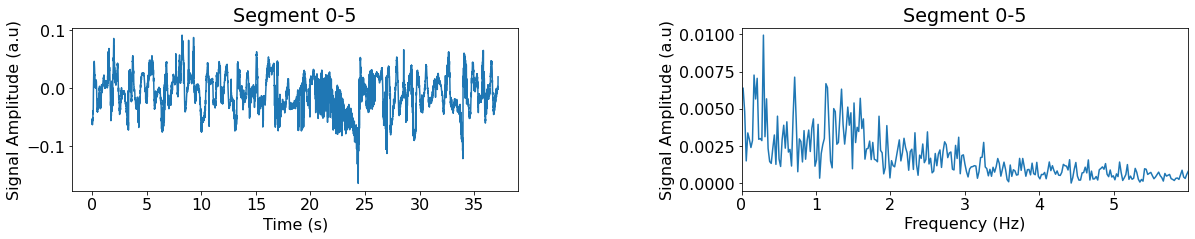

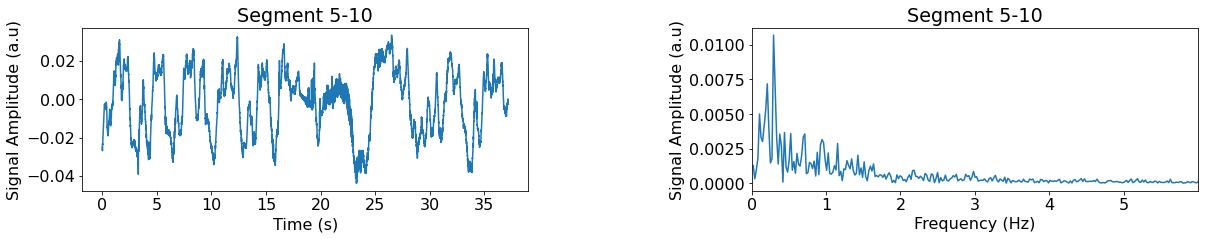

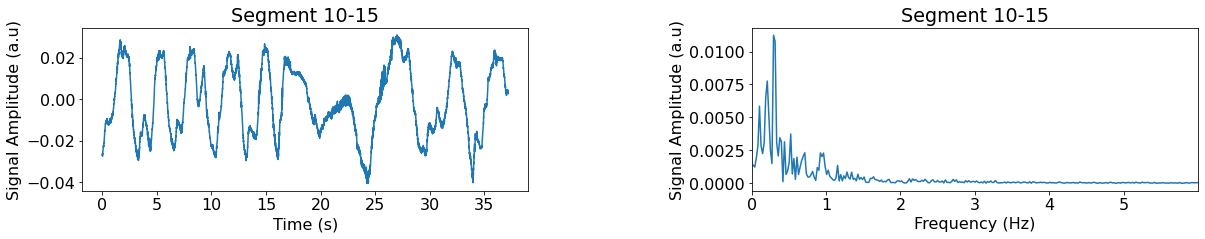

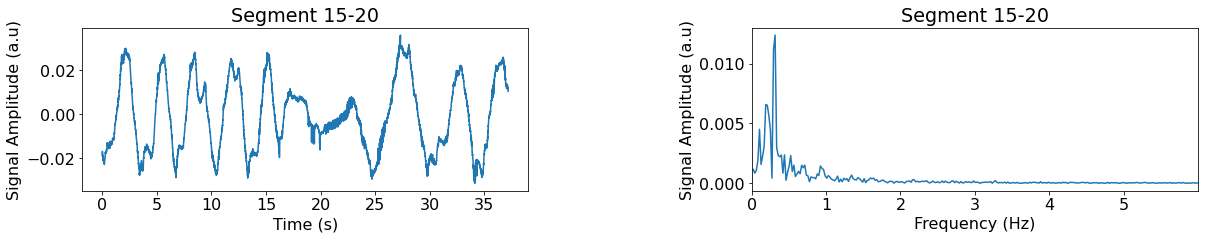

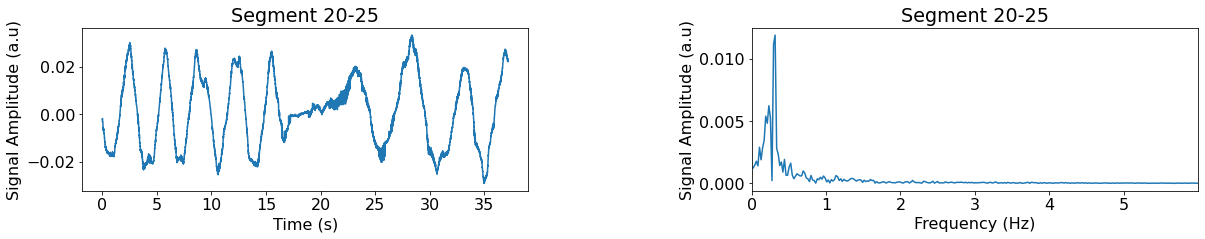

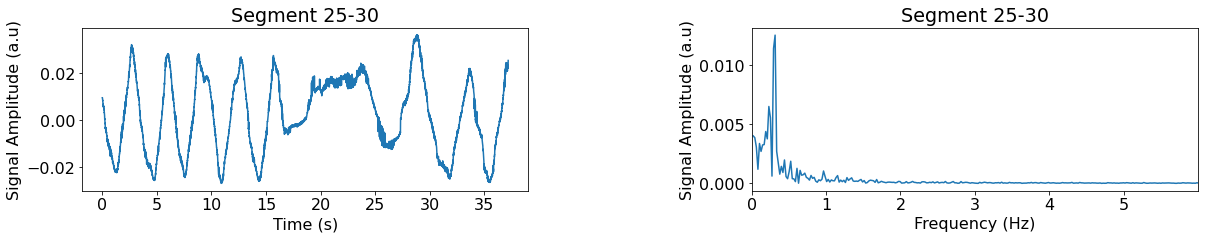

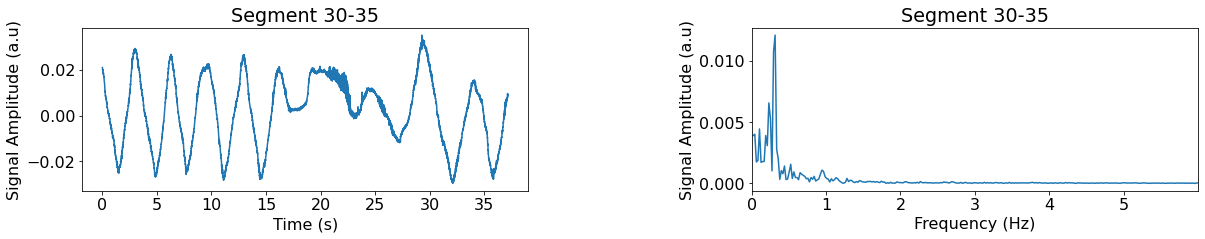

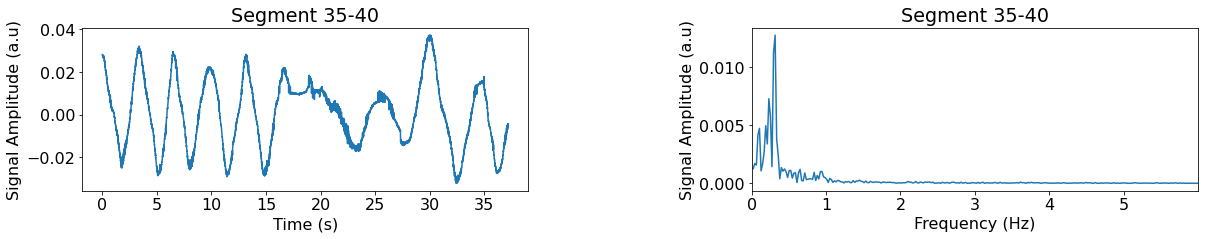

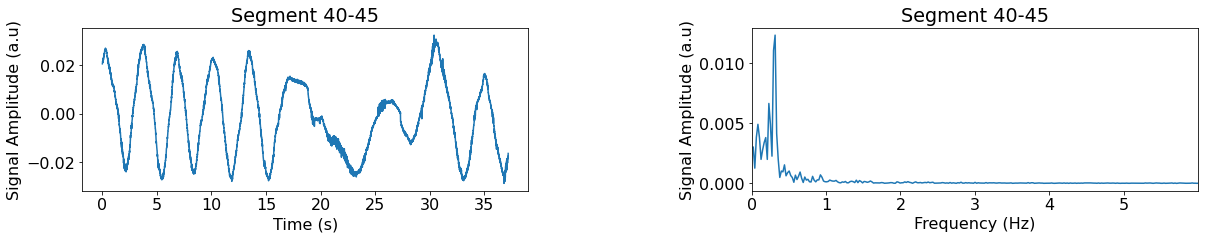

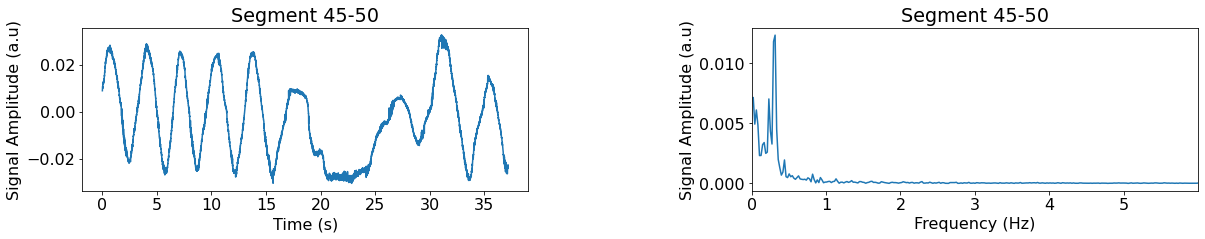

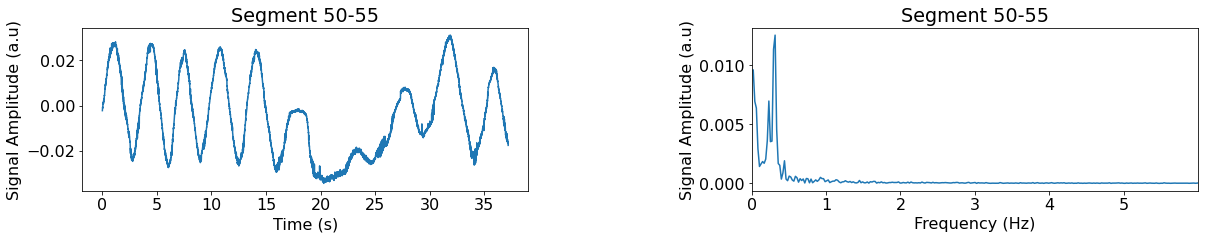

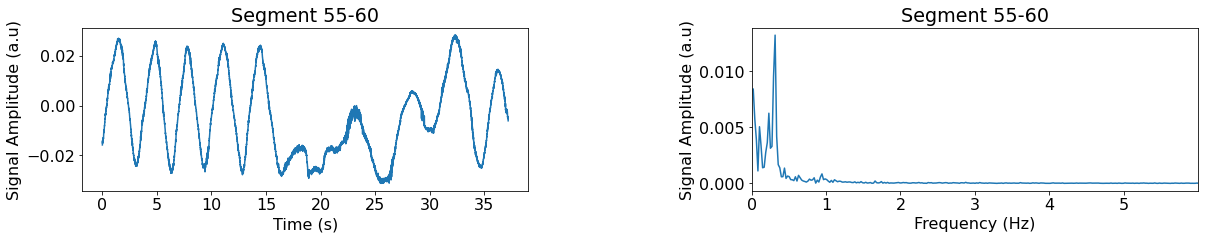

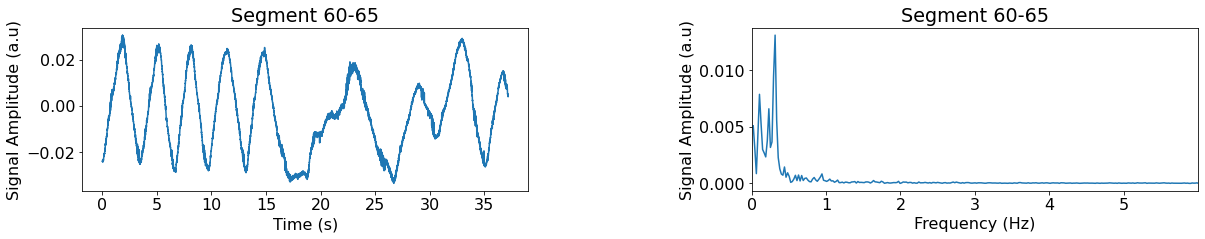

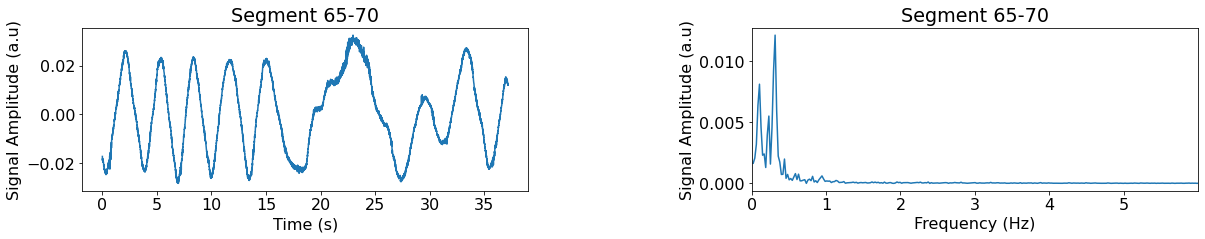

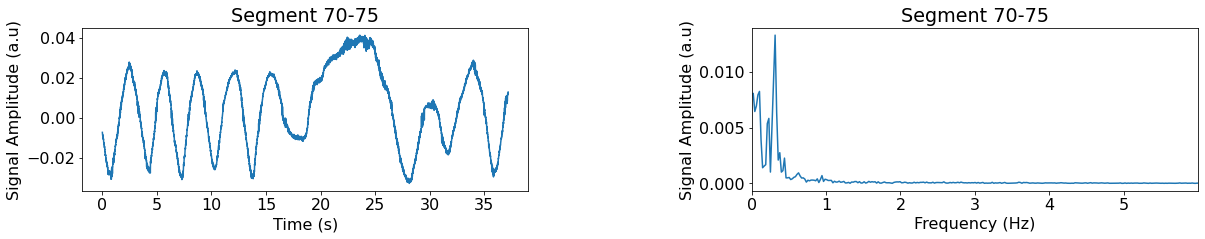

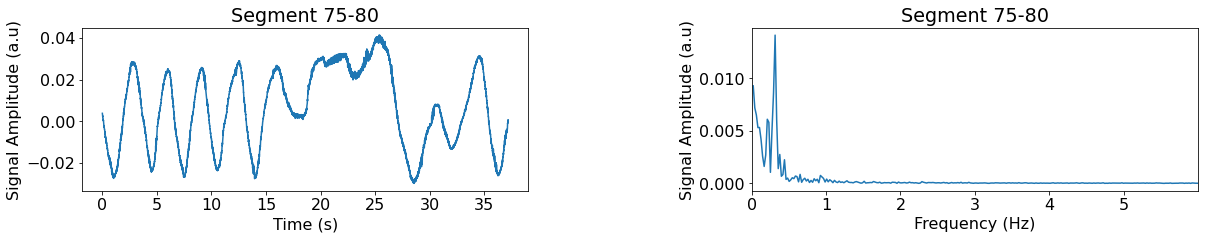

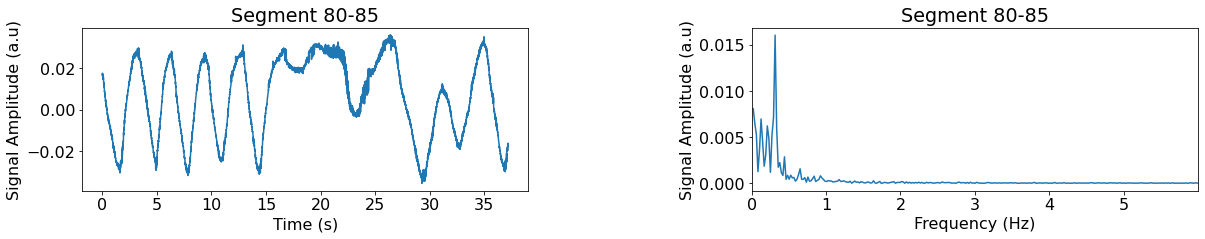

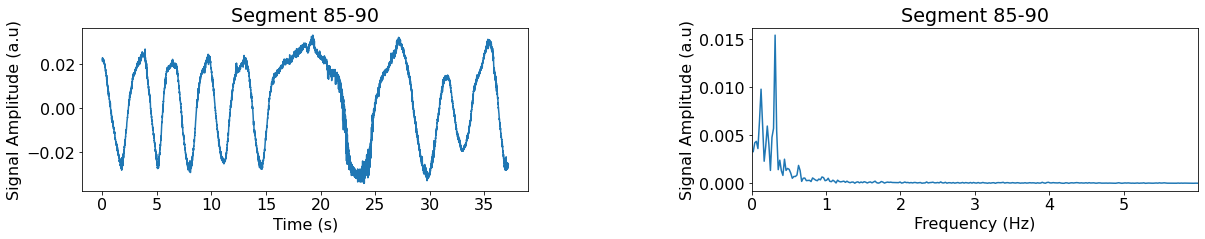

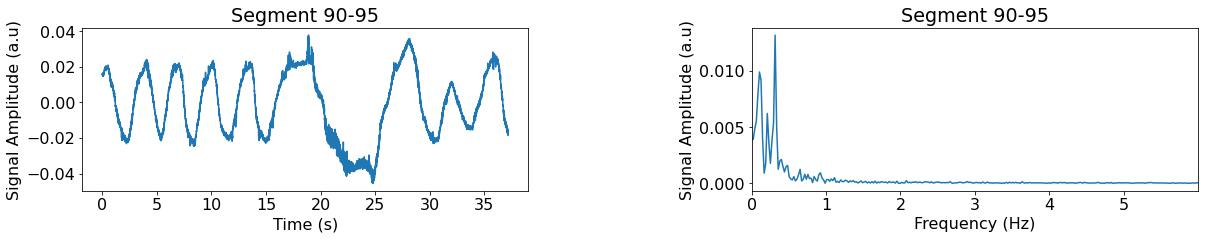

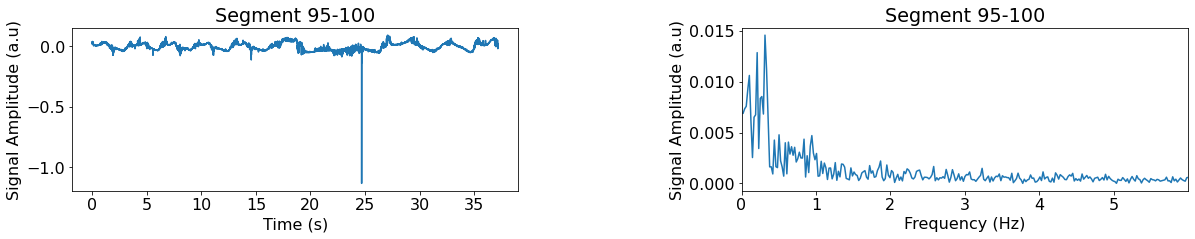

In [11]:

#start_frame=0
#end_frame=1000
start_freq=0 #range of requencys which should be displayed
end_freq=6 #range of requencys which should be displayed
fps=167.0 #frames per second
win=5
save=0
for idx,segment in enumerate(Kt_avg):
    x_axis,y_axis=fourier_transform(Kt_avg,fps,segment)
    fourier_plot(x_axis,y_axis,start_frame,end_frame,start_freq,end_freq,win,fps,segment,idx,save)